In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")

random_state = 42

In [10]:
df = pd.read_csv('data/balanced_dropout_dataset.csv')
print(df.shape)
df.head()

(4482, 18)


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Year of study,Department,Parental_Education,Dropout
0,19.2,0,25000.0,1,4.08,76.8,5,20.7,0,0,9.3,2.26,2.42,2.40,2,Engineering,Bachelor,1
1,21.3,1,36634.0,0,2.57,86.2,1,41.4,0,0,6.2,1.98,1.70,1.70,1,Engineering,High School,0
2,20.6,0,42980.0,1,2.94,78.9,4,45.8,0,0,6.2,1.65,1.53,1.56,4,Science,Bachelor,1
3,21.4,1,25000.0,1,4.94,75.5,1,51.4,1,1,5.3,2.18,2.20,2.20,1,Business,High School,1
4,21.5,1,97830.0,1,4.48,77.6,2,31.5,1,1,6.0,0.46,0.92,0.92,1,CS,High School,1


count    4482.000000
mean        5.792503
std         1.771336
min         1.000000
25%         4.600000
50%         5.800000
75%         7.000000
max        10.000000
Name: Stress_Index, dtype: float64


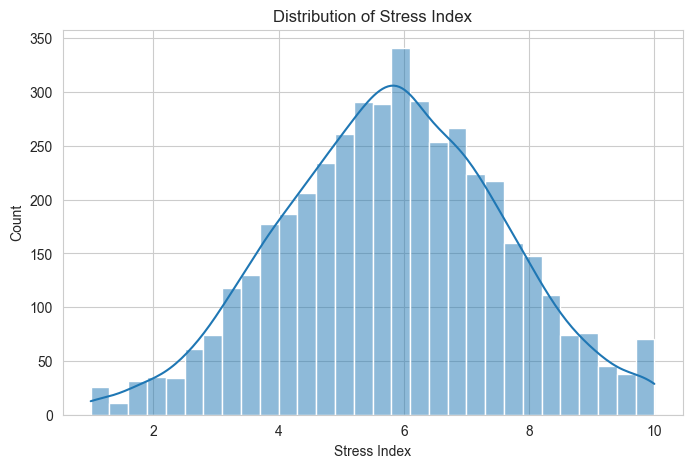

In [11]:
print(df['Stress_Index'].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df['Stress_Index'], kde=True, bins=30)
plt.title('Distribution of Stress Index')
plt.xlabel('Stress Index')
plt.show()

In [12]:
df.corr(numeric_only=True)['Stress_Index'].sort_values(ascending=False)

Stress_Index             1.000000
Dropout                  0.297623
Assignment_Delay_Days    0.008702
Study_Hours_per_Day      0.005060
Part_Time_Job            0.003428
Gender                   0.000825
Year of study           -0.004164
Family_Income           -0.006375
Age                     -0.008825
Scholarship             -0.009271
Travel_Time_Minutes     -0.015716
Internet_Access         -0.019592
Attendance_Rate         -0.041739
CGPA                    -0.370311
Semester_GPA            -0.370391
GPA                     -0.389483
Name: Stress_Index, dtype: float64

In [ ]:
y = df["Stress_Index"]

# Remove the target and Student_ID
X = df.drop(columns=["Stress_Index", "Student_ID", "Dropout"], errors="ignore")

print("Features:", X.columns.tolist())
print("Target:", y.name)

Features: ['Age', 'Gender', 'Family_Income', 'Internet_Access', 'Study_Hours_per_Day', 'Attendance_Rate', 'Assignment_Delay_Days', 'Travel_Time_Minutes', 'Part_Time_Job', 'Scholarship', 'GPA', 'Semester_GPA', 'CGPA', 'Year of study', 'Department', 'Parental_Education', 'Dropout']
Target: Stress_Index


In [13]:
selected_features = ['GPA', 'Semester_GPA', 'CGPA', 'Dropout']

X_reduced = df[selected_features]
y_reduced = df['Stress_Index']

X_reduced.head()

,GPA,Semester_GPA,CGPA,Dropout
0,2.26,2.42,2.40,1
1,1.98,1.70,1.70,0
2,1.65,1.53,1.56,1
3,2.18,2.20,2.20,1
4,0.46,0.92,0.92,1


# Check for Categorical variables
- Catboost has an added advantage in that it can work with categorical variables directly.

In [15]:
# Identify categorical columns
categorical_features = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

Categorical features:
['Department', 'Parental_Education']


In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=random_state
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (3585, 17)
Testing data: (897, 17)


In [ ]:
catboost_regressor = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=random_state,
    verbose=False
)

catboost_regressor.fit(
    X_train,
    y_train,
    cat_features=categorical_features
)
)
# Save the stress model without future-outcome features.
catboost_regressor.save_model("models/catboost_stress_model.cbm")
import joblib
joblib.dump(catboost_regressor, "models/catboost_stress_model.pkl")

CatBoostRegressor(depth=6, iterations=500, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=False)

In [23]:
y_pred = catboost_regressor.predict(X_test)

print("First 10 actual stress scores:")
print(y_test.head(10).values)

print("\nFirst 10 predicted stress scores:")
print(y_pred[:10])

First 10 actual stress scores:
[6.2 7.3 6.6 7.3 6.9 5.4 6.2 6.5 5.3 7.1]

First 10 predicted stress scores:
[5.54736769 6.50890671 6.35703154 6.33330481 5.91474851 5.64903504
 5.19164904 6.93401328 6.2774181  5.949534  ]


In [24]:
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("CatBoost Regression Results")
print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

CatBoost Regression Results
MAE  : 1.3184
RMSE : 1.6444
R²   : 0.1058


# Plot Actual vs Predicted stress

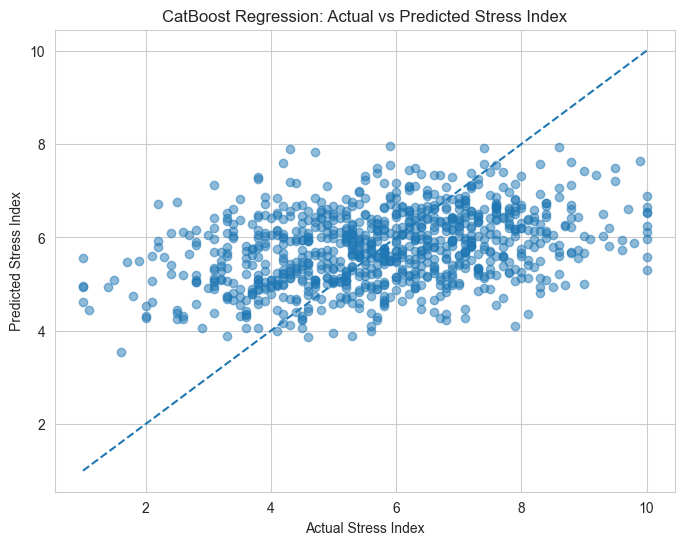

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel("Actual Stress Index")
plt.ylabel("Predicted Stress Index")
plt.title("CatBoost Regression: Actual vs Predicted Stress Index")

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)


plt.show()

# Check For feature Importance
- check which variables the model considers imnportant when predicting stress

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": catboost_regressor.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

                  Feature  Importance
10                    GPA   13.946234
7     Travel_Time_Minutes   12.275584
4     Study_Hours_per_Day   10.163344
5         Attendance_Rate    9.187426
0                     Age    8.744792
11           Semester_GPA    7.645561
2           Family_Income    7.292185
12                   CGPA    6.048961
16                Dropout    4.675750
15     Parental_Education    4.629203
13          Year of study    4.256486
14             Department    3.153146
6   Assignment_Delay_Days    3.022496
1                  Gender    1.930234
9             Scholarship    1.098576
8           Part_Time_Job    0.996597
3         Internet_Access    0.933426


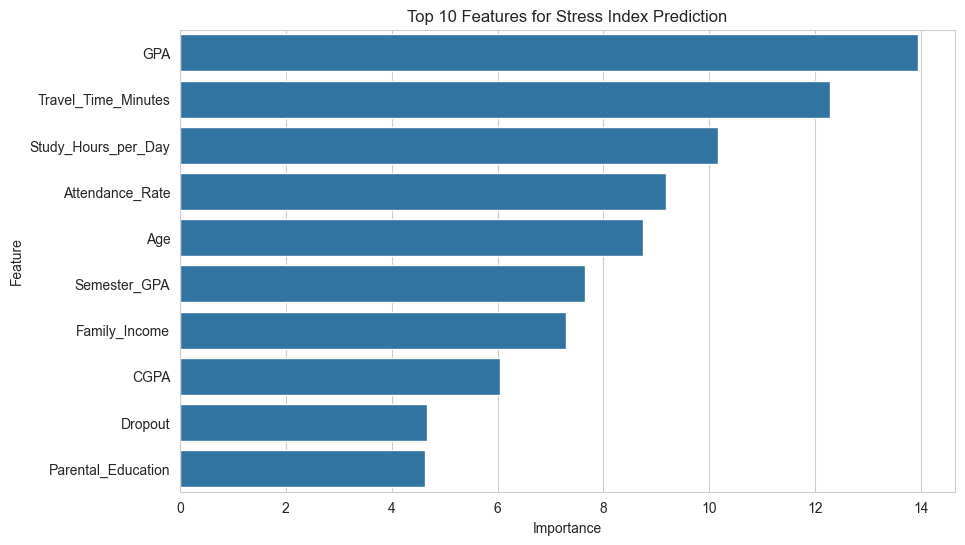

In [27]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features for Stress Index Prediction")
plt.show()